In [100]:
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
Path("../figs/eda/customers").mkdir(parents=True, exist_ok=True)

con = duckdb.connect("../data/capstone.duckdb")

### Check null values

In [101]:
# Get column names dynamically
cols = con.execute("DESCRIBE silver.customers").df()['column_name'].tolist()

# Querying missing values and looping through all columns
null_checks = ', '.join([f"COUNT(*) - COUNT({c}) AS {c}" for c in cols])
missing = con.execute(f"SELECT {null_checks} FROM silver.customers").fetchone()

for col, nulls in zip(cols, missing):
    if nulls > 0:
        print(f"  {col}: {nulls:,} missing")

  NAICSCode: 234,885 missing
  OriginalCustomerDate: 24 missing
  RelationshipYears: 24 missing
  RelationshipMonths: 24 missing


### Customers Overview

In [102]:
query = con.execute("""
                    SELECT 
                    COUNT(*) AS total_customers,
                    COUNT(distinct CustomerID) AS unique_customers,
                    SUM(CASE WHEN Individual = 'Y' THEN 1 ELSE 0 END) AS individuals,
                    SUM(CASE WHEN Individual = 'N' THEN 1 ELSE 0 END) AS non_individuals
                    FROM silver.customers
                    """).fetchone()

print(f"Total customer rows: {query[0]:,}")
print(f"Total unique customers: {query[1]:,}")
print(f"Total individual customers: {query[2]:,}")
print(f"Total non-individual customers: {query[3]:,}")

Total customer rows: 276,836
Total unique customers: 276,836
Total individual customers: 236,426
Total non-individual customers: 40,410


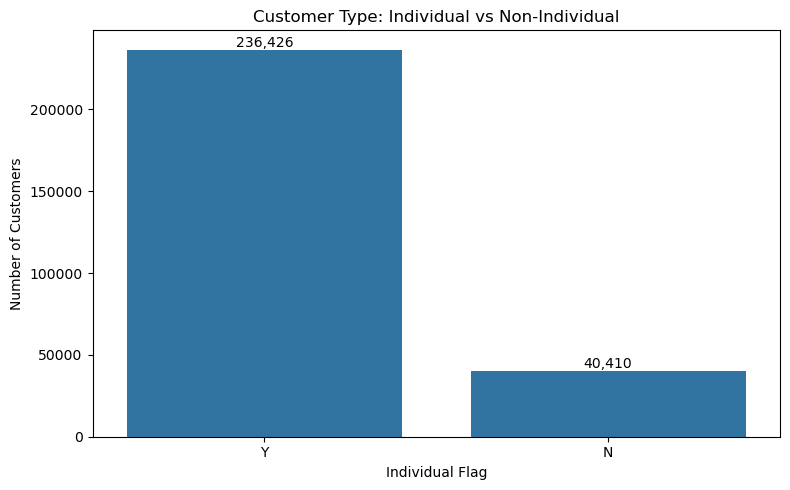

In [103]:
df_overview = con.execute("""
    SELECT Individual, COUNT(*) AS count
    FROM silver.customers
    GROUP BY Individual
    ORDER BY count DESC
""").fetchdf()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_overview, x='Individual', y='count', ax=ax)
ax.set_title('Customer Type: Individual vs Non-Individual')
ax.set_xlabel('Individual Flag')
ax.set_ylabel('Number of Customers')
for i, row in df_overview.iterrows():
    ax.text(i, row['count'], f"{row['count']:,}", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/customers/customer_types.png", dpi=150, bbox_inches='tight')
plt.show()

### Age Distribution

In [104]:
query = con.execute("""
    SELECT 
        COUNT(*) AS total,
        COUNT(Age) AS with_age,
        ROUND(MIN(Age), 1) AS min_age,
        ROUND(MAX(Age), 1) AS max_age,
        ROUND(AVG(Age), 1) AS avg_age,
        ROUND(MEDIAN(Age), 1) AS median_age
    FROM silver.customers
""").fetchone()

print(f"Customers with age: {query[1]:,} / {query[0]:,}")
print(f"Min age:    {query[2]}")
print(f"Max age:    {query[3]}")
print(f"Mean age :   {query[4]}")
print(f"Median age: {query[5]}")

Customers with age: 276,836 / 276,836
Min age:    0
Max age:    126
Mean age :   41.9
Median age: 43.0


In [105]:
con.execute("""
    SELECT Age, COUNT(*) AS Customers
    FROM silver.customers
    WHERE Age > 100
    GROUP BY ROLLUP(Age)
    ORDER BY Age DESC NULLS FIRST
""").df()

,Age,Customers
0,<NA>,139
1,126,4
2,125,2
3,120,1
4,118,2
5,115,1
6,114,3
7,113,2
8,111,2
9,110,2


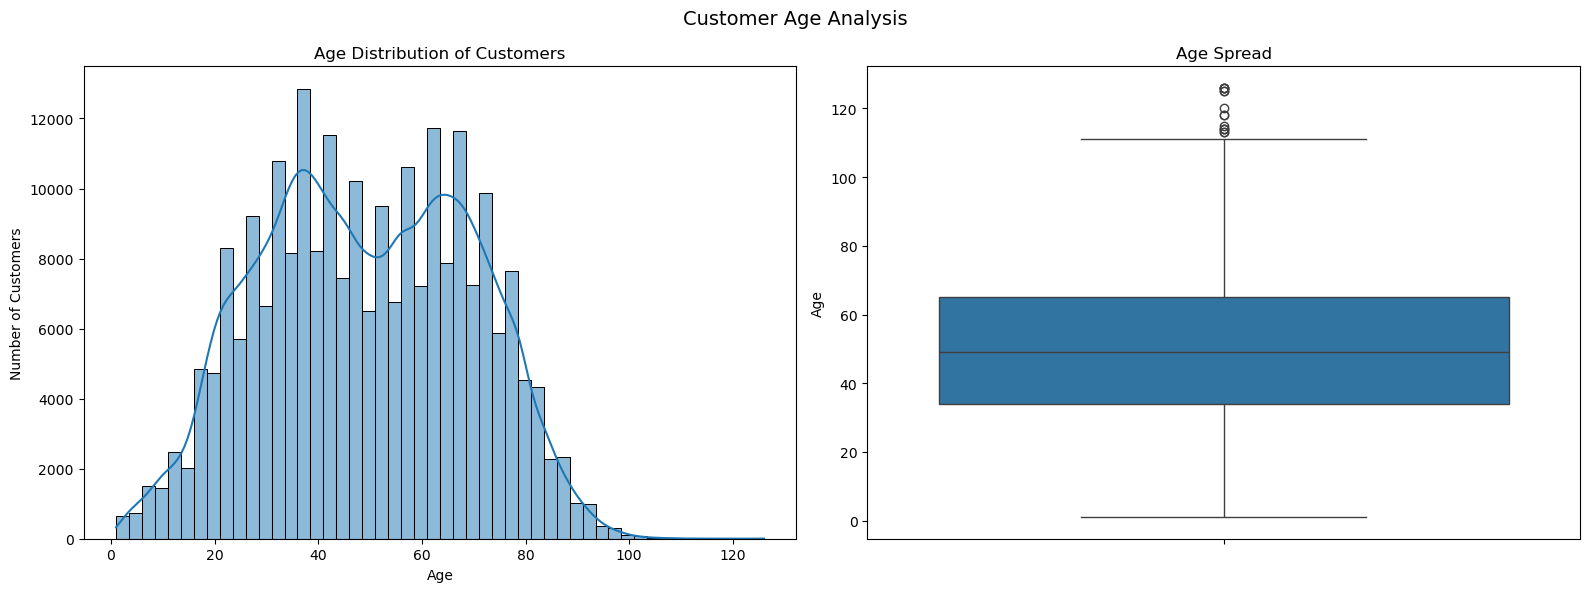

In [106]:
df_age = con.execute("""
    SELECT Age
    FROM silver.customers
    WHERE Age IS NOT NULL AND Age <> 0
""").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df_age, x='Age', bins=50, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution of Customers')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Customers')

sns.boxplot(data=df_age, y='Age', ax=axes[1])
axes[1].set_title('Age Spread')
axes[1].set_ylabel('Age')

plt.suptitle('Customer Age Analysis', fontsize=14)
plt.tight_layout()
fig.savefig("../figs/eda/customers/customer_age.png", dpi=150, bbox_inches='tight')
plt.show()

### Analyzing Relationships

In [107]:
query = con.execute("""
    SELECT 
        ROUND(MIN(RelationshipYears), 1) AS min_years,
        ROUND(MAX(RelationshipYears), 1) AS max_years,
        ROUND(AVG(RelationshipYears), 1) AS avg_years,
        ROUND(MEDIAN(RelationshipYears), 1) AS median_years
    FROM silver.customers
""").fetchone()

print(f"Min rel age:    {query[0]} years")
print(f"Max rel age:    {query[1]} years")
print(f"Mean rel age:   {query[2]} years")
print(f"Median rel age: {query[3]} years")

Min rel age:    0 years
Max rel age:    85 years
Mean rel age:   13.3 years
Median rel age: 10.0 years


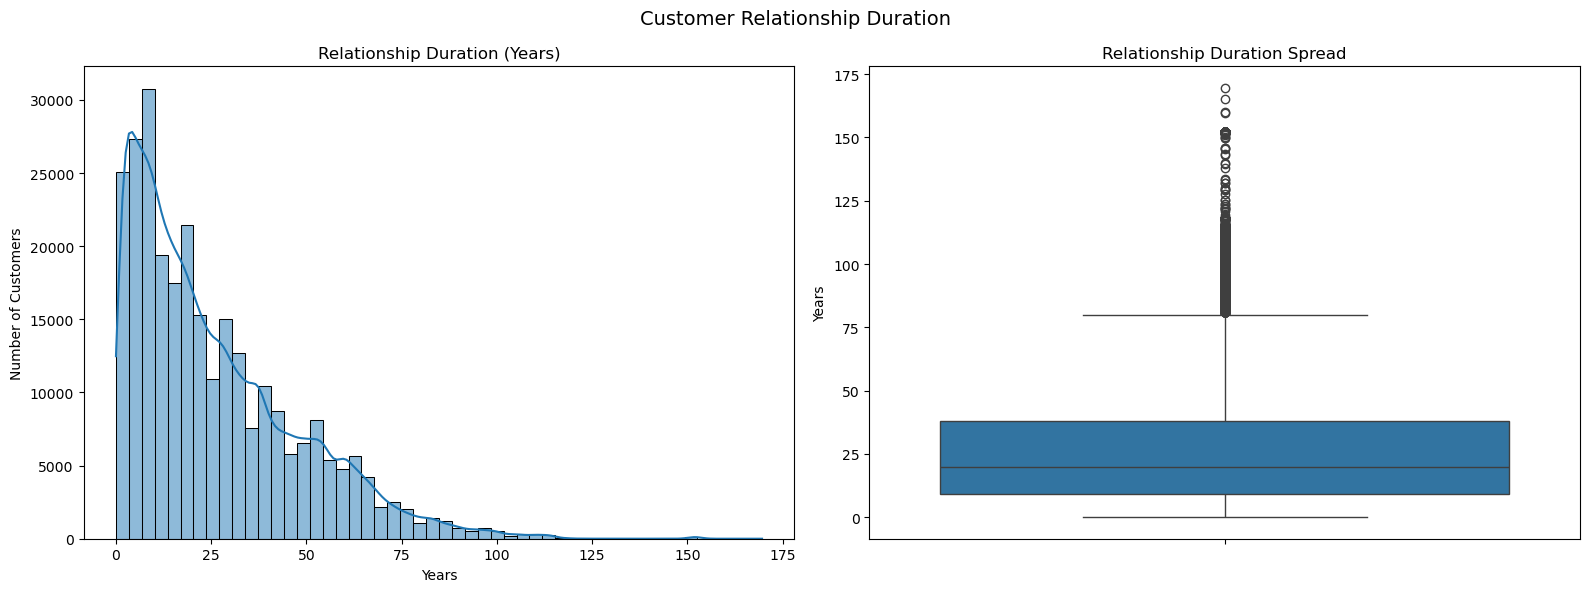

In [108]:
df_relationship = con.execute("""
    SELECT (RelationshipYears * 12 + RelationshipMonths) AS relationship_total_months
    FROM silver.customers
    WHERE RelationshipYears IS NOT NULL
""").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df_relationship, x=df_relationship['relationship_total_months'] / 12, bins=50, kde=True, ax=axes[0])
axes[0].set_title('Relationship Duration (Years)')
axes[0].set_xlabel('Years')
axes[0].set_ylabel('Number of Customers')

sns.boxplot(data=df_relationship, y=df_relationship['relationship_total_months']/12, ax=axes[1])
axes[1].set_title('Relationship Duration Spread')
axes[1].set_ylabel('Years')

plt.suptitle('Customer Relationship Duration', fontsize=14)
plt.tight_layout()
fig.savefig("../figs/eda/customers/customer_relationship.png", dpi=150, bbox_inches='tight')
plt.show()

### Various products and holdings

In [109]:
query = con.execute("""
    SELECT 
        SUM(CASE WHEN ActiveDebitCard = 'Y' THEN 1 ELSE 0 END) AS active_debit,
        SUM(CASE WHEN ActiveATMCard = 'Y' THEN 1 ELSE 0 END) AS active_atm,
        SUM(CASE WHEN DepositAccount = 'Y' THEN 1 ELSE 0 END) AS deposit_acct,
        SUM(CASE WHEN LoanAccount = 'Y' THEN 1 ELSE 0 END) AS loan_acct,
        SUM(CASE WHEN CreditCardAccount = 'Y' THEN 1 ELSE 0 END) AS credit_card,
        SUM(CASE WHEN TimeDepositAccount = 'Y' THEN 1 ELSE 0 END) AS time_deposit,
        COUNT(*) AS total
    FROM silver.customers
""").fetchone()

total = query[6]
print(f"Active Debit Card:    {query[0]:,} ({query[0]/total*100:.1f}%)")
print(f"Active ATM Card:      {query[1]:,} ({query[1]/total*100:.1f}%)")
print(f"Deposit Account:      {query[2]:,} ({query[2]/total*100:.1f}%)")
print(f"Loan Account:         {query[3]:,} ({query[3]/total*100:.1f}%)")
print(f"Credit Card Account:  {query[4]:,} ({query[4]/total*100:.1f}%)")
print(f"Time Deposit Account: {query[5]:,} ({query[5]/total*100:.1f}%)")

Active Debit Card:    180,912 (65.3%)
Active ATM Card:      8,229 (3.0%)
Deposit Account:      260,161 (94.0%)
Loan Account:         57,175 (20.7%)
Credit Card Account:  6,391 (2.3%)
Time Deposit Account: 14,336 (5.2%)


### Checking boolean value columns - 

In [110]:
query = con.execute("""
    SELECT 
        SUM(CASE WHEN TPS = true THEN 1 ELSE 0 END) AS tps,
        SUM(CASE WHEN Payroll = true THEN 1 ELSE 0 END) AS payroll,
        SUM(CASE WHEN Merchant = true THEN 1 ELSE 0 END) AS merchant,
        SUM(CASE WHEN BangorWealth = true THEN 1 ELSE 0 END) AS bangor_wealth,
        SUM(CASE WHEN PlingCustomer = true THEN 1 ELSE 0 END) AS pling,
        SUM(CASE WHEN ABLECustomer = true THEN 1 ELSE 0 END) AS able,
        COUNT(*) AS total
    FROM silver.customers
""").fetchone()

total = query[6]
print(f"TPS (Treasury and Payment Services): {query[0]:,} ({query[0]/total*100:.1f}%)")
print(f"Payroll:                             {query[1]:,} ({query[1]/total*100:.1f}%)")
print(f"Merchant:                            {query[2]:,} ({query[2]/total*100:.1f}%)")
print(f"BangorWealth:                        {query[3]:,} ({query[3]/total*100:.1f}%)")
print(f"PlingCustomer:                       {query[4]:,} ({query[4]/total*100:.1f}%)")
print(f"ABLECustomer:                        {query[5]:,} ({query[5]/total*100:.1f}%)")

TPS (Treasury and Payment Services): 2,872 (1.0%)
Payroll:                             5,066 (1.8%)
Merchant:                            1,257 (0.5%)
BangorWealth:                        2,239 (0.8%)
PlingCustomer:                       625 (0.2%)
ABLECustomer:                        1,930 (0.7%)


### Gender distribution

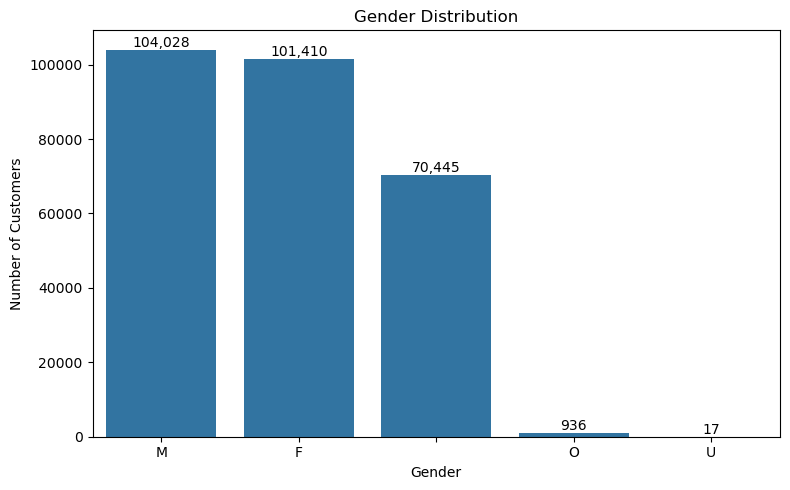

In [111]:
df_gender = con.execute("""
    SELECT Gender, COUNT(*) AS count
    FROM silver.customers
    GROUP BY Gender
    ORDER BY count DESC
""").fetchdf()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_gender, x='Gender', y='count', ax=ax)
ax.set_title('Gender Distribution')
ax.set_xlabel('Gender')
ax.set_ylabel('Number of Customers')
for i, row in df_gender.iterrows():
    ax.text(i, row['count'], f"{row['count']:,}", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/customers/customer_genders.png", dpi=150, bbox_inches='tight')
plt.show()

In [112]:
con.execute("""
    SELECT Individual, Gender, COUNT(*) as count
    FROM silver.customers
    GROUP BY Individual, Gender
    ORDER BY Individual, count DESC
""").df()

,Individual,Gender,count
0,N,,39542
1,N,M,839
2,N,F,20
3,N,O,9
4,Y,M,103189
5,Y,F,101390
6,Y,,30903
7,Y,O,927
8,Y,U,17


### Types of accounts and loans

In [113]:
query = con.execute("""
    SELECT 
        ROUND(AVG(NumberActiveDDAs), 2) AS avg_ddas,
        ROUND(AVG(NumberActiveTimeDeposits), 2) AS avg_time_deposits,
        ROUND(AVG(NumberActiveLoans), 2) AS avg_loans,
        ROUND(AVG(NumberCreditCardAccts), 2) AS avg_credit_cards,
        MAX(NumberActiveDDAs) AS max_ddas,
        MAX(NumberActiveTimeDeposits) AS max_time_deposits,
        MAX(NumberActiveLoans) AS max_loans,
        MAX(NumberCreditCardAccts) AS max_credit_cards
    FROM silver.customers
""").fetchone()

print(f"{'Account Type':<25} {'Avg':<10} {'Max':<10}")
print(f"{'Active DDAs':<25} {query[0]:<10} {int(query[4]):<10}")
print(f"{'Active Time Deposits':<25} {query[1]:<10} {int(query[5]):<10}")
print(f"{'Active Loans':<25} {query[2]:<10} {int(query[6]):<10}")
print(f"{'Credit Card Accounts':<25} {query[3]:<10} {int(query[7]):<10}")

Account Type              Avg        Max       
Active DDAs               1.87       227       
Active Time Deposits      0.08       27        
Active Loans              0.27       15        
Credit Card Accounts      0.02       2         


### Primary Banking Customer Flag

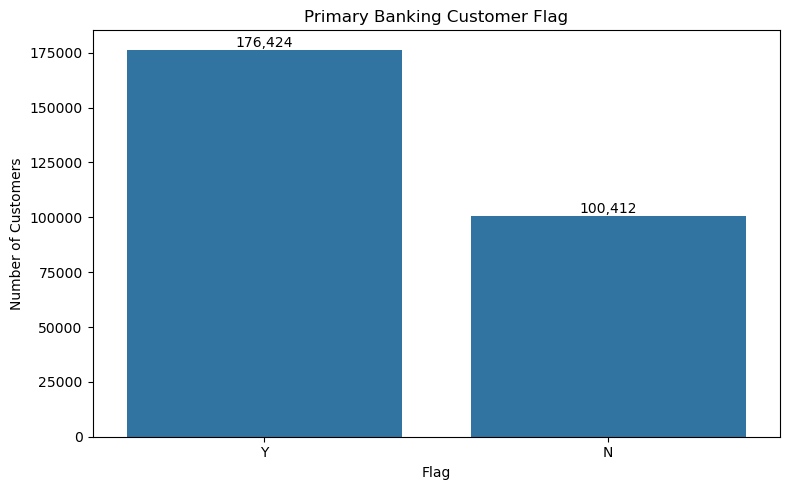

In [114]:
df_primary = con.execute("""
    SELECT PrimaryBankingCustomerFlag, COUNT(*) AS count
    FROM silver.customers
    GROUP BY PrimaryBankingCustomerFlag
    ORDER BY count DESC
""").fetchdf()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_primary, x='PrimaryBankingCustomerFlag', y='count', ax=ax)
ax.set_title('Primary Banking Customer Flag')
ax.set_xlabel('Flag')
ax.set_ylabel('Number of Customers')
for i, row in df_primary.iterrows():
    ax.text(i, row['count'], f"{row['count']:,}", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/customers/customer_primary.png", dpi=150, bbox_inches='tight')
plt.show()

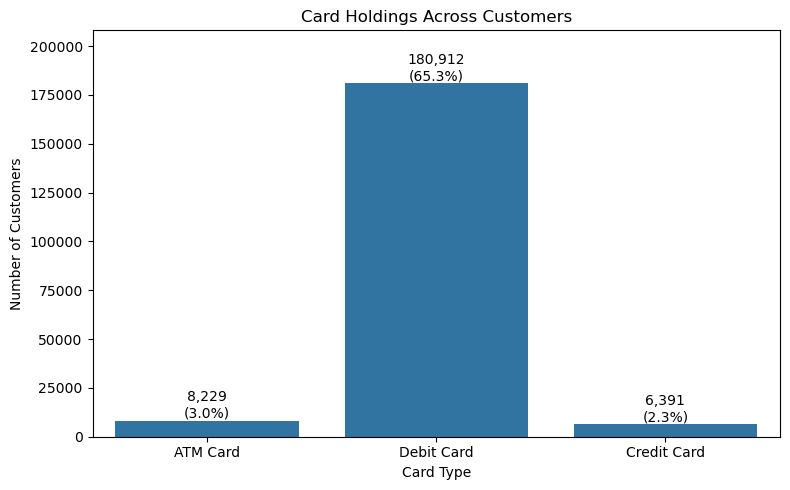

In [115]:
# Card holdings 
df_cards = con.execute("""
    SELECT 'ATM Card' AS type, COUNT(*) AS count FROM silver.customers WHERE ActiveATMCard = 'Y'
    UNION ALL
    SELECT 'Debit Card', COUNT(*) FROM silver.customers WHERE ActiveDebitCard = 'Y'
    UNION ALL
    SELECT 'Credit Card', COUNT(*) FROM silver.customers WHERE CreditCardAccount = 'Y'
""").fetchdf()

total = con.execute("SELECT COUNT(*) FROM silver.customers").fetchone()[0]

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_cards, x='type', y='count', ax=ax)
ax.set_title('Card Holdings Across Customers')
ax.set_xlabel('Card Type')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, df_cards['count'].max() * 1.15)
for i, row in df_cards.iterrows():
    pct = row['count'] / total * 100
    ax.text(i, row['count'], f"{row['count']:,}\n({pct:.1f}%)", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/customers/customer_holdings.png", dpi=150, bbox_inches='tight')
plt.show()

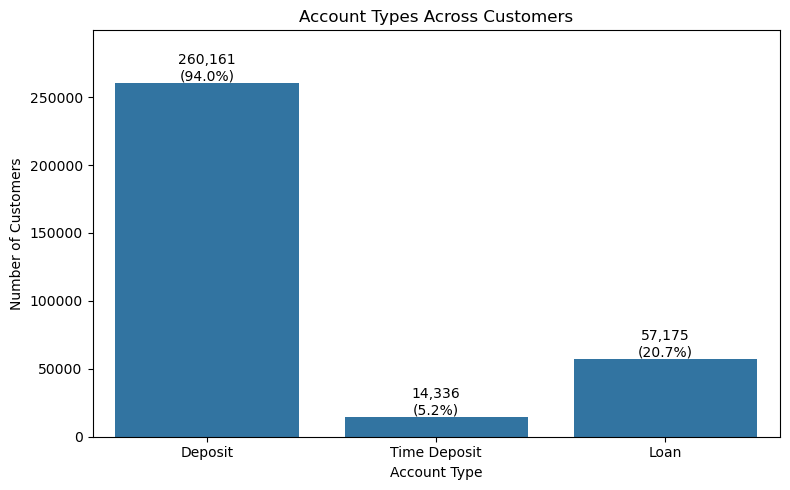

In [116]:
# Account types 
df_accounts = con.execute("""
    SELECT 'Deposit' AS type, COUNT(*) AS count FROM silver.customers WHERE DepositAccount = 'Y'
    UNION ALL
    SELECT 'Time Deposit', COUNT(*) FROM silver.customers WHERE TimeDepositAccount = 'Y'
    UNION ALL
    SELECT 'Loan', COUNT(*) FROM silver.customers WHERE LoanAccount = 'Y'
""").fetchdf()

total = con.execute("SELECT COUNT(*) FROM silver.customers").fetchone()[0]

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_accounts, x='type', y='count', ax=ax)
ax.set_title('Account Types Across Customers')
ax.set_xlabel('Account Type')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, df_accounts['count'].max() * 1.15)
for i, row in df_accounts.iterrows():
    pct = row['count'] / total * 100
    ax.text(i, row['count'], f"{row['count']:,}\n({pct:.1f}%)", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/customers/customer_accounts.png", dpi=150, bbox_inches='tight')
plt.show()

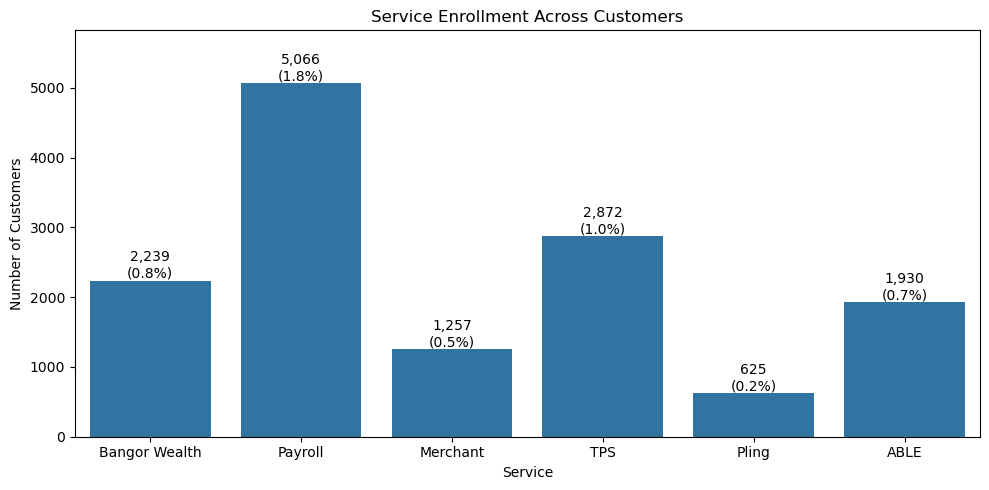

In [117]:
# Services enrolled
df_services = con.execute("""
    SELECT 'Bangor Wealth' AS type, COUNT(*) AS count FROM silver.customers WHERE BangorWealth = TRUE
    UNION ALL
    SELECT 'Payroll', COUNT(*) FROM silver.customers WHERE Payroll = TRUE
    UNION ALL
    SELECT 'Merchant', COUNT(*) FROM silver.customers WHERE Merchant = TRUE
    UNION ALL
    SELECT 'TPS', COUNT(*) FROM silver.customers WHERE TPS = TRUE
    UNION ALL
    SELECT 'Pling', COUNT(*) FROM silver.customers WHERE PlingCustomer = TRUE
    UNION ALL
    SELECT 'ABLE', COUNT(*) FROM silver.customers WHERE ABLECustomer = TRUE
""").fetchdf()

total = con.execute("SELECT COUNT(*) FROM silver.customers").fetchone()[0]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_services, x='type', y='count', ax=ax)
ax.set_title('Service Enrollment Across Customers')
ax.set_xlabel('Service')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, df_services['count'].max() * 1.15)
for i, row in df_services.iterrows():
    pct = row['count'] / total * 100
    ax.text(i, row['count'], f"{row['count']:,}\n({pct:.1f}%)", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/customers/customer_services.png", dpi=150, bbox_inches='tight')
plt.show()

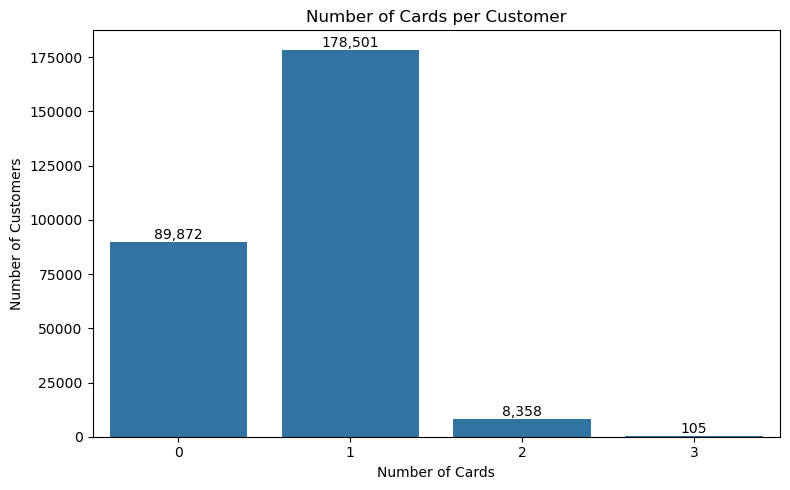

In [118]:
# Cards per customer
df_cards_per_customer = con.execute("""
    SELECT 
        (CASE WHEN ActiveATMCard = 'Y' THEN 1 ELSE 0 END +
         CASE WHEN ActiveDebitCard = 'Y' THEN 1 ELSE 0 END +
         CASE WHEN CreditCardAccount = 'Y' THEN 1 ELSE 0 END) AS card_count
    FROM silver.customers
""").fetchdf()

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df_cards_per_customer, x='card_count', ax=ax)
ax.set_title('Number of Cards per Customer')
ax.set_xlabel('Number of Cards')
ax.set_ylabel('Number of Customers')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height(),
            f"{int(p.get_height()):,}", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/customers/customer_cards.png", dpi=150, bbox_inches='tight')
plt.show()

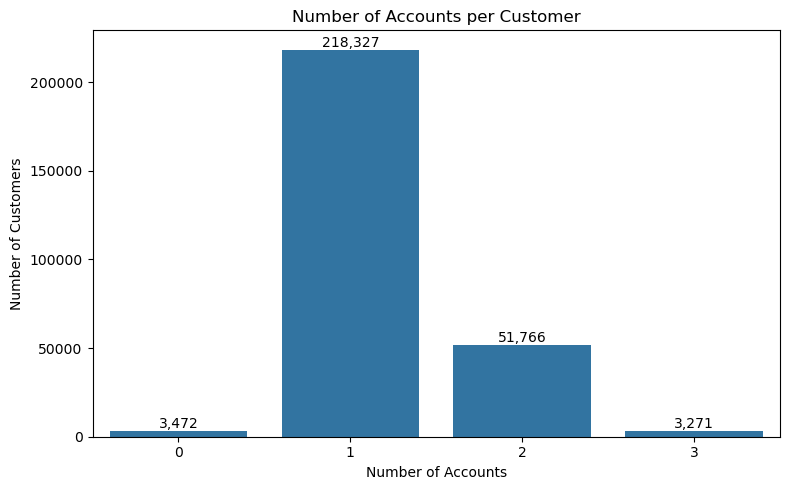

In [119]:
# Accounts per customer
df_accounts_per_customer = con.execute("""
    SELECT 
        (CASE WHEN DepositAccount = 'Y' THEN 1 ELSE 0 END +
         CASE WHEN TimeDepositAccount = 'Y' THEN 1 ELSE 0 END +
         CASE WHEN LoanAccount = 'Y' THEN 1 ELSE 0 END) AS account_count
    FROM silver.customers
""").fetchdf()

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df_accounts_per_customer, x='account_count', ax=ax)
ax.set_title('Number of Accounts per Customer')
ax.set_xlabel('Number of Accounts')
ax.set_ylabel('Number of Customers')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height(),
            f"{int(p.get_height()):,}", ha='center', va='bottom')
plt.tight_layout()
fig.savefig("../figs/eda/customers/customer_accountno.png", dpi=150, bbox_inches='tight')
plt.show()

In [120]:
con.close()